## EDA on AQI India data

In [123]:
#import standard data sci libs
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

!pip install chart_studio
import chart_studio.plotly as py
import plotly.graph_objs as go
from plotly.offline import iplot, init_notebook_mode
import cufflinks
cufflinks.go_offline()
cufflinks.set_config_file(world_readable=True, theme='pearl')

In [124]:
df = pd.read_csv('city_day.csv')
df

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,Visakhapatnam,2020-06-27,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,0.73,41.0,Good
29527,Visakhapatnam,2020-06-28,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38,70.0,Satisfactory
29528,Visakhapatnam,2020-06-29,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,0.00,68.0,Satisfactory
29529,Visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.00,0.00,54.0,Satisfactory


In [125]:
# show columns
df.columns

Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')

In [126]:
df.shape

(29531, 16)

In [127]:
df.info()  # more info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [128]:
# null counts
df.isnull().sum()

,0
City,0
Date,0
PM2.5,4598
PM10,11140
NO,3582
NO2,3585
NOx,4185
NH3,10328
CO,2059
SO2,3854


In [129]:
df.describe()  # data statistics

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


In [130]:
# convert 'Date' to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Extract time features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Quarter'] = df['Date'].dt.quarter

df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,...,Benzene,Toluene,Xylene,AQI,AQI_Bucket,Year,Month,Day,DayOfWeek,Quarter
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,...,0.00,0.02,0.00,NaN,NaN,2015,1,1,3,1
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,...,3.68,5.50,3.77,NaN,NaN,2015,1,2,4,1
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,...,6.80,16.40,2.25,NaN,NaN,2015,1,3,5,1
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,...,4.43,10.14,1.00,NaN,NaN,2015,1,4,6,1
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,...,7.01,18.89,2.78,NaN,NaN,2015,1,5,0,1


#### looking at the missing values

In [131]:
# Missing values
def missing_values_table(df):
        # Total missing values
        mis_val = df.isnull().sum()

        # Percentage of missing values
        mis_val_percent = 100 * df.isnull().sum() / len(df)

        # Make a table with the results
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)

        # Rename the columns
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})

        # Sort the table by percentage of missing descending
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)

        # Print some summary information
        print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"
            "There are " + str(mis_val_table_ren_columns.shape[0]) +
              " columns that have missing values.")

        # Return the dataframe with missing information
        return mis_val_table_ren_columns

missing_values= missing_values_table(df)
missing_values.style.background_gradient(cmap='Reds')

Your selected dataframe has 21 columns.
There are 14 columns that have missing values.


,Missing Values,% of Total Values
Xylene,18109,61.300000
PM10,11140,37.700000
NH3,10328,35.000000
Toluene,8041,27.200000
Benzene,5623,19.000000
AQI,4681,15.900000
AQI_Bucket,4681,15.900000
PM2.5,4598,15.600000
NOx,4185,14.200000
O3,4022,13.600000


#### Visualising yearly data:

In [132]:
city_day = df.copy()

In [133]:
city_day['BTX'] = city_day['Benzene']+city_day['Toluene']+city_day['Xylene']
city_day.drop(['Benzene','Toluene','Xylene'],axis=1);

In [134]:
city_day['Particulate_Matter'] = city_day['PM2.5']+city_day['PM10']

In [135]:
pollutants = ['PM2.5','PM10','NO2', 'CO', 'SO2','O3', 'BTX']

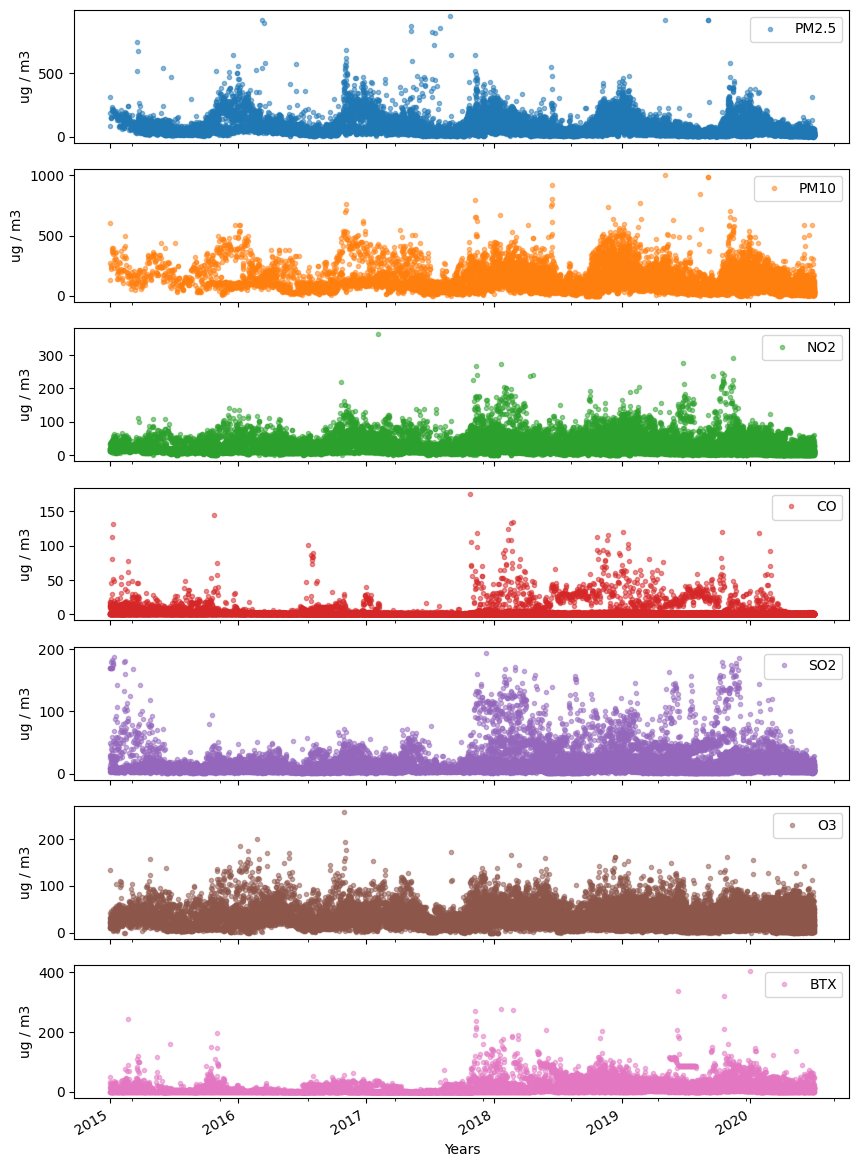

In [136]:
city_day.set_index('Date',inplace=True)
axes = city_day[pollutants].plot(marker='.', alpha=0.5, linestyle='None', figsize=(10, 16), subplots=True)
for ax in axes:

    ax.set_xlabel('Years')
    ax.set_ylabel('ug / m3')


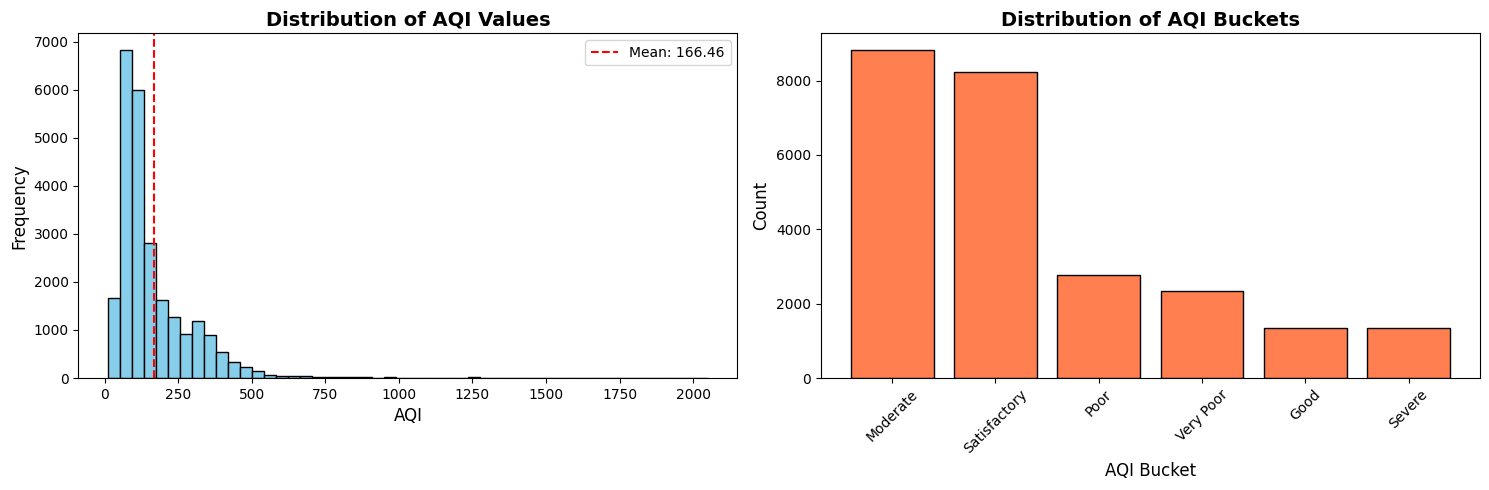


AQI Statistics:
Mean AQI: 166.46
Median AQI: 118.00
Min AQI: 13.00
Max AQI: 2049.00


In [137]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# AQI distribution
axes[0].hist(df['AQI'].dropna(), bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of AQI Values', fontsize=14, fontweight='bold')
axes[0].set_xlabel('AQI', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].axvline(df['AQI'].mean(), color='red', linestyle='--', label=f'Mean: {df["AQI"].mean():.2f}')
axes[0].legend()

# AQI Bucket distribution
aqi_bucket_counts = df['AQI_Bucket'].value_counts()
axes[1].bar(aqi_bucket_counts.index, aqi_bucket_counts.values, color='coral', edgecolor='black')
axes[1].set_title('Distribution of AQI Buckets', fontsize=14, fontweight='bold')
axes[1].set_xlabel('AQI Bucket', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()
print(f"\nAQI Statistics:")
print(f"Mean AQI: {df['AQI'].mean():.2f}")
print(f"Median AQI: {df['AQI'].median():.2f}")
print(f"Min AQI: {df['AQI'].min():.2f}")
print(f"Max AQI: {df['AQI'].max():.2f}")

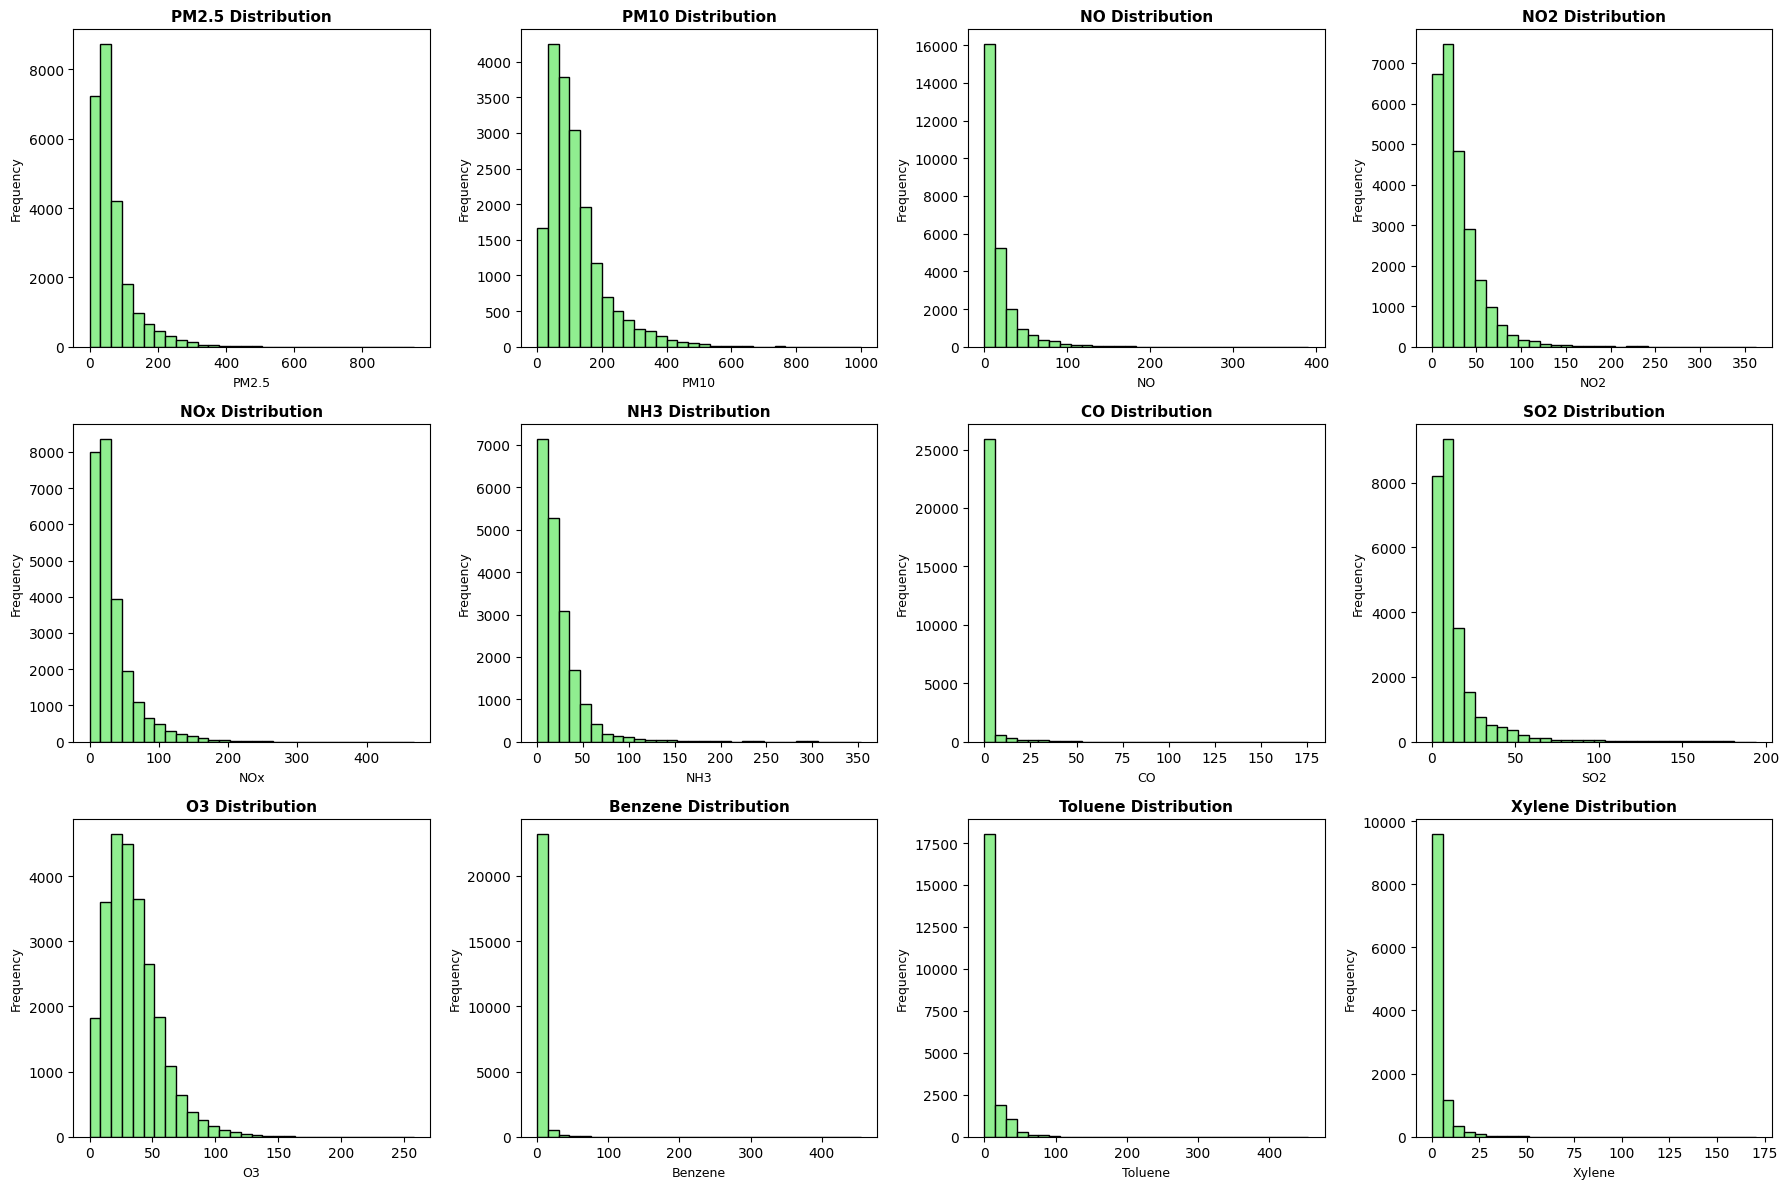

In [138]:
# Pollutant Analysis
pollutants = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']

# Remove pollutants with too many missing values
available_pollutants = [p for p in pollutants if p in df.columns and df[p].notna().sum() > 100]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for idx, pollutant in enumerate(available_pollutants):
    if idx < len(axes):
        axes[idx].hist(df[pollutant].dropna(), bins=30, color='lightgreen', edgecolor='black')
        axes[idx].set_title(f'{pollutant} Distribution', fontsize=11, fontweight='bold')
        axes[idx].set_xlabel(pollutant, fontsize=9)
        axes[idx].set_ylabel('Frequency', fontsize=9)

# Hide unused subplots
for idx in range(len(available_pollutants), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

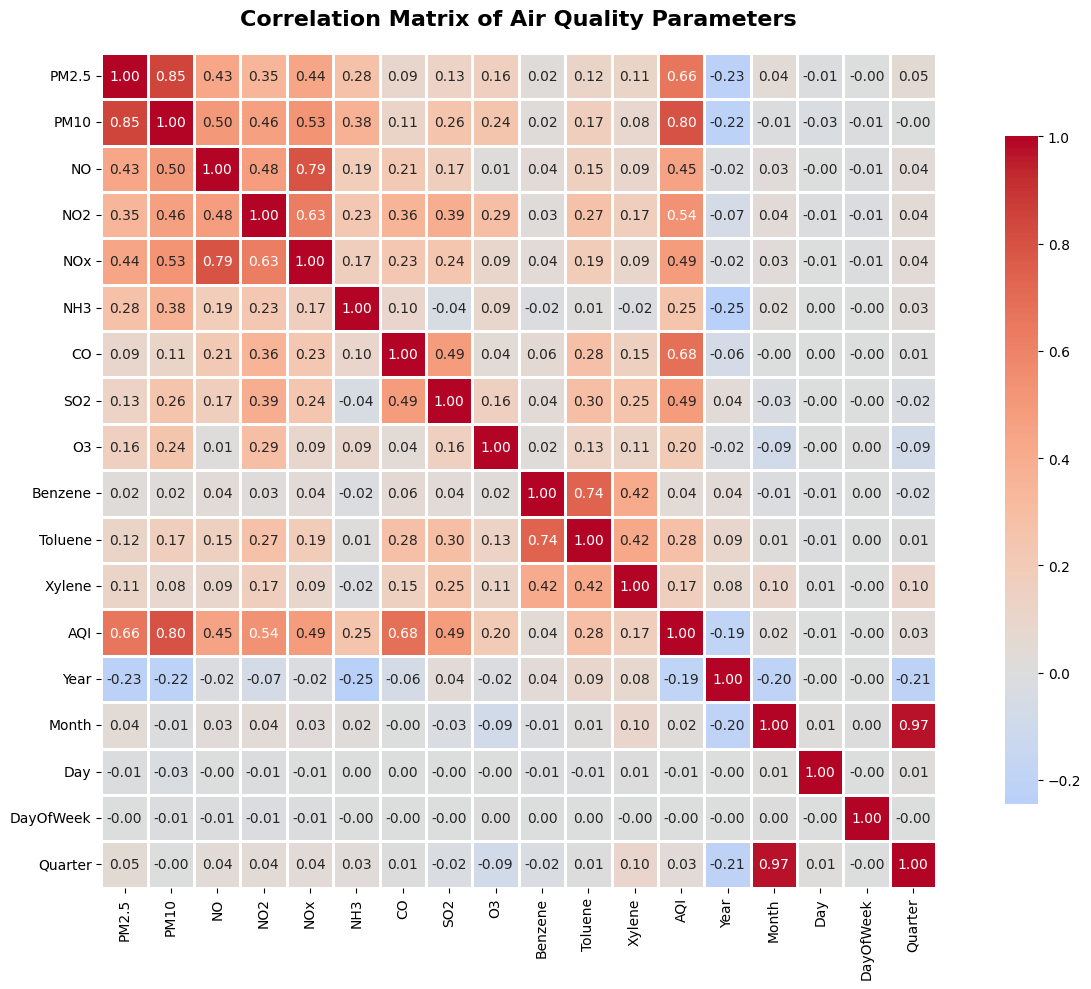


Correlation with AQI:
PM10       0.803313
CO         0.683346
PM2.5      0.659181
NO2        0.537071
SO2        0.490586
NOx        0.486450
NO         0.452191
Toluene    0.279992
NH3        0.252019
O3         0.198991
Name: AQI, dtype: float64


In [139]:
# Select numeric columns for correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Air Quality Parameters', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Show strong correlations with AQI
if 'AQI' in correlation_matrix.columns:
    aqi_corr = correlation_matrix['AQI'].sort_values(ascending=False)
    print("\nCorrelation with AQI:")
    print(aqi_corr[1:11])

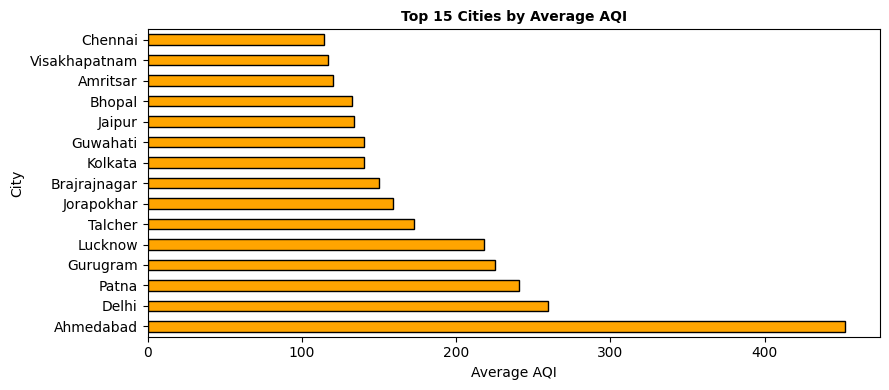

In [140]:
# Top 15 cities by average AQI
city_aqi = df.groupby('City')['AQI'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 4))
city_aqi.plot(kind='barh', color='orange', edgecolor='black')
plt.title('Top 15 Cities by Average AQI', fontsize=10, fontweight='bold')
plt.xlabel('Average AQI', fontsize=10)
plt.ylabel('City', fontsize=10)
plt.tight_layout()
plt.show()

In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   City        29531 non-null  object        
 1   Date        29531 non-null  datetime64[ns]
 2   PM2.5       24933 non-null  float64       
 3   PM10        18391 non-null  float64       
 4   NO          25949 non-null  float64       
 5   NO2         25946 non-null  float64       
 6   NOx         25346 non-null  float64       
 7   NH3         19203 non-null  float64       
 8   CO          27472 non-null  float64       
 9   SO2         25677 non-null  float64       
 10  O3          25509 non-null  float64       
 11  Benzene     23908 non-null  float64       
 12  Toluene     21490 non-null  float64       
 13  Xylene      11422 non-null  float64       
 14  AQI         24850 non-null  float64       
 15  AQI_Bucket  24850 non-null  object        
 16  Year        29531 non-

###preprocessing

In [142]:
pollutant_cols = [
    'PM2.5','PM10','NO','NO2','NOx','NH3',
    'CO','SO2','O3','Benzene','Toluene','Xylene','AQI'
]
df = df.dropna(subset=pollutant_cols, how='all')
df = df.reset_index(drop=True)
print("Rows after removing empty pollutant rows:", len(df))


Rows after removing empty pollutant rows: 28157


In [143]:
# Interpolate all numerical columns
df_interp = df.interpolate(method='linear')

# Fill any leftover NaNs with column median
df_interp = df_interp.fillna(df_interp.median(numeric_only=True))


/tmp/ipython-input-3827237244.py:2: FutureWarning:

DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.



In [144]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_interp['City'] = le.fit_transform(df_interp['City'])


In [145]:
aqi_map = {
    'Good': 0,
    'Satisfactory': 1,
    'Moderate': 2,
    'Poor': 3,
    'Very Poor': 4,
    'Severe': 5
}

df_interp['AQI_Bucket'] = df_interp['AQI_Bucket'].map(aqi_map)


In [146]:
#Lag Features

df_interp['AQI_lag1'] = df_interp['AQI'].shift(1)
df_interp['PM25_lag1'] = df_interp['PM2.5'].shift(1)
df_interp['PM10_lag1'] = df_interp['PM10'].shift(1)

In [147]:
#Moving Averages

df_interp['PM25_MA3'] = df_interp['PM2.5'].rolling(window=3).mean()
df_interp['AQI_MA5'] = df_interp['AQI'].rolling(window=5).mean()

# Drop rows created by lag/MA
df_interp = df_interp.dropna().reset_index(drop=True)


In [148]:
#Feature Selection

features = [
    'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3',
    'AQI_lag1', 'PM25_MA3', 'AQI_MA5'
]

target = 'AQI'

X = df_interp[features]
y = df_interp[target]


#Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [149]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Select input features (pollutants + lag features)
feature_columns = ['PM2.5','PM10','NO2','SO2','CO','O3','AQI_lag1','PM25_MA3','AQI_MA5']
X = df_interp[feature_columns]

# Scale inputs to [0,1]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Replace original columns with scaled values
df_scaled = df_interp.copy()
df_scaled[feature_columns] = X_scaled

# Save scaled dataset to CSV for MATLAB
df_scaled.to_csv('cleaned_aqi_scaled.csv', index=False)



In [150]:
# Save scaled dataset to CSV for MATLAB
df_scaled.to_csv('cleaned_aqi.csv', index=False)

##Random Forest model implementation

In [155]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Input features (scaled)
feature_columns = ['PM2.5','PM10','NO2','SO2','CO','O3','AQI_lag1','PM25_MA3','AQI_MA5']
X = df_scaled[feature_columns]

# Target (AQI in original scale)
y = df_scaled['AQI']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [156]:
# Train Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=200,  # number of trees
    max_depth=15,      # maximum depth of each tree
    random_state=42,
    n_jobs=-1          # use all CPUs
)
rf_model.fit(X_train, y_train)

# Predict on Test Set
y_pred = rf_model.predict(X_test)

# Evaluate Model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'Random Forest RMSE: {rmse:.2f}')
print(f'Random Forest R^2: {r2:.3f}')

Random Forest RMSE: 37.03
Random Forest R^2: 0.925


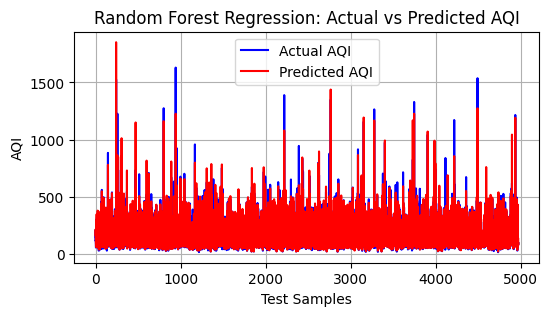

In [157]:
# Plot Actual vs Predicted
plt.figure(figsize=(6,3))
plt.plot(y_test.values, 'b', label='Actual AQI')
plt.plot(y_pred, 'r', label='Predicted AQI')
plt.xlabel('Test Samples')
plt.ylabel('AQI')
plt.title('Random Forest Regression: Actual vs Predicted AQI')
plt.legend()
plt.grid(True)
plt.show()